# Model 1 - Course to Category classifier

**Task:** supervised multi-class text classification. Input = `Title + Short Intro`,
output = one of 11 categories. Trained on the **frozen split** in `data/processed/`.

Follows `docs/MODEL_PLAN.md`: majority baseline -> TF-IDF + Logistic Regression ->
TF-IDF -> SVD -> MLP. We tune on **dev**, report on **test once**, and write every
final number to `data/processed/` so the report is built from files, not this notebook.

> Run top to bottom. Requires: pandas, numpy, scikit-learn, matplotlib (install via Anaconda).

In [1]:
import sys, time, json
from pathlib import Path
import numpy as np
import pandas as pd

# Locate the repo root (folder that contains data/processed) so this notebook
# works whether launched from the repo root or from notebooks/.
here = Path.cwd()
REPO_ROOT = here if (here / "data" / "processed").exists() else here.parent
sys.path.insert(0, str(REPO_ROOT))

from src.data_contract import (DATA_PROCESSED, LABEL_COL, TEXT_COLS,
                               TITLE_COL, INTRO_COL, SEED)
np.random.seed(SEED)
print("repo root:", REPO_ROOT)

repo root: C:\Users\jimal\02_University\Year 4\Pre-master\Software Engineering for CSAI\Software-Engineering---Group-7


## 1. Load the frozen split

In [2]:
def load(name):
    df = pd.read_csv(DATA_PROCESSED / f"{name}.csv")
    # Model 1 input is Title + Short Intro; fill the few missing intros.
    df["text"] = (df[TITLE_COL].fillna("") + ". " + df[INTRO_COL].fillna("")).str.strip()
    return df

train, dev, test = load("train"), load("dev"), load("test")
print(f"train {len(train)} | dev {len(dev)} | test {len(test)}")
print("classes:", train[LABEL_COL].nunique())
train[[*TEXT_COLS, LABEL_COL, "text"]].head()

train 1805 | dev 386 | test 386
classes: 11


,title,short_intro,category,text
0,"Dense Gases, Liquids and Solids",Course 4 of Statistical Thermodynamics address...,Physical Science and Engineering,"Dense Gases, Liquids and Solids. Course 4 of S..."
1,Low Poly Art For Video Games,This course is aimed to give you the tools and...,Arts and Humanities,Low Poly Art For Video Games. This course is a...
2,"Android App Components - Intents, Activities, ...",This 4 week MOOC builds upon the overview of J...,Computer Science,"Android App Components - Intents, Activities, ..."
3,Developing Cloud Apps with Node.js and React,"In a recent Stack Overflow survey, Node.js was...",Computer Science,Developing Cloud Apps with Node.js and React. ...
4,"Python for Data Science, AI & Development",Kickstart your learning of Python with this be...,Data Science,"Python for Data Science, AI & Development. Kic..."


In [3]:
X_train, y_train = train["text"], train[LABEL_COL]
X_dev,   y_dev   = dev["text"],   dev[LABEL_COL]
X_test,  y_test  = test["text"],  test[LABEL_COL]

# Class balance - this is why macro-F1 matters more than accuracy.
train[LABEL_COL].value_counts()

category
Business                            576
Computer Science                    292
Data Science                        265
Health                              179
Information Technology              139
Physical Science and Engineering    105
Arts and Humanities                  71
Language Learning                    59
Social Sciences                      58
Personal Development                 45
Math and Logic                       16
Name: count, dtype: int64

## 2. Metrics helper

Always report **accuracy AND macro-F1** side by side (MODEL_PLAN.md section 6).
Macro-F1 averages over classes so the Business majority cannot flatter the score.

In [4]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def evaluate(name, model, X, y_true, results):
    t0 = time.perf_counter()
    y_pred = model.predict(X)
    infer_s = time.perf_counter() - t0
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name:32s}  acc={acc:.3f}  macro-F1={macro_f1:.3f}  "
          f"(infer {infer_s*1000/len(y_true):.2f} ms/item)")
    results.append({"model": name, "accuracy": round(acc, 4),
                    "macro_f1": round(macro_f1, 4),
                    "infer_ms_per_item": round(infer_s*1000/len(y_true), 3)})
    return y_pred

dev_results = []

## 3. Baseline 1 - majority class (the floor)

In [5]:
from sklearn.dummy import DummyClassifier

majority = DummyClassifier(strategy="most_frequent", random_state=SEED)
majority.fit(X_train, y_train)
evaluate("majority-baseline", majority, X_dev, y_dev, dev_results);

majority-baseline                 acc=0.321  macro-F1=0.044  (infer 0.00 ms/item)


## 4. Baseline 2 - TF-IDF + Logistic Regression

The linear baseline. class_weight='balanced' counteracts the imbalance.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                              stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=SEED)),
])
t0 = time.perf_counter()
logreg.fit(X_train, y_train)
logreg_train_s = time.perf_counter() - t0
print(f"trained in {logreg_train_s:.2f}s")
evaluate("tfidf-logreg", logreg, X_dev, y_dev, dev_results);

trained in 0.62s
tfidf-logreg                      acc=0.806  macro-F1=0.752  (infer 0.13 ms/item)


## 5. The trained model - TF-IDF -> SVD -> MLP

A real trained neural model: TF-IDF, reduced with truncated SVD, into a small MLP.
Trains in seconds. This is the "not too simple, not too complex" target (section 3).

In [7]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                              stop_words="english")),
    ("svd", TruncatedSVD(n_components=300, random_state=SEED)),
    ("scale", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(256,), max_iter=200,
                          early_stopping=False, random_state=SEED)),
])
t0 = time.perf_counter()
mlp.fit(X_train, y_train)
train_s = time.perf_counter() - t0
print(f"trained in {train_s:.2f}s | epochs run: {mlp.named_steps['clf'].n_iter_}")
evaluate("tfidf-svd-mlp", mlp, X_dev, y_dev, dev_results);

# --- training statistics (rubric: statistics presented; audit rule 7) ---
clf = mlp.named_steps["clf"]
mlp_stats = {
    "train_seconds": round(train_s, 2),
    "epochs_run": int(clf.n_iter_),
    "max_iter": 200,
    "loss_curve": [round(float(l), 5) for l in clf.loss_curve_],
    "final_loss": round(float(clf.loss_), 5),
    "hidden_layer_sizes": list(clf.hidden_layer_sizes),
    "svd_components": 300,
}
print(f"MLP: {mlp_stats['epochs_run']} epochs, final loss {mlp_stats['final_loss']}")

trained in 7.18s | epochs run: 92
tfidf-svd-mlp                     acc=0.811  macro-F1=0.724  (infer 0.09 ms/item)
MLP: 92 epochs, final loss 0.02245


### Training loss curve (MLP neural model)


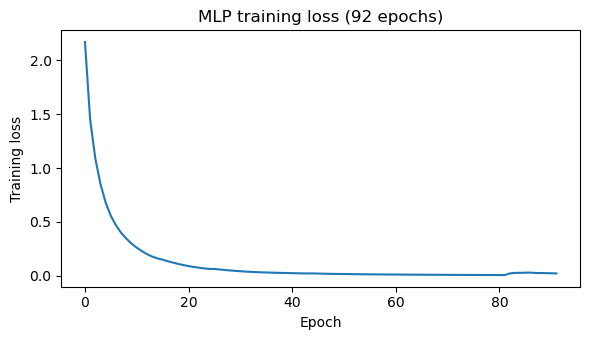

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(clf.loss_curve_)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training loss")
ax.set_title(f"MLP training loss ({clf.n_iter_} epochs)")
fig.tight_layout()
fig.savefig(DATA_PROCESSED / "model1_loss_curve.png", dpi=120)
plt.show()

In [9]:
# Dev comparison table - this IS the 'training statistics' the rubric asks for.
dev_table = pd.DataFrame(dev_results).sort_values("macro_f1", ascending=False)
dev_table

,model,accuracy,macro_f1,infer_ms_per_item
1,tfidf-logreg,0.8057,0.7517,0.127
2,tfidf-svd-mlp,0.8109,0.7239,0.093
0,majority-baseline,0.3212,0.0442,0.001


## 6. Final evaluation on TEST - once only

Pick the best model by **dev** macro-F1, then score **test** a single time (section 6:
"dev selects, test reports"). If macro-F1 > 0.90 here, suspect leakage before celebrating.

In [10]:
best_name = dev_table.iloc[0]["model"]
best_model = {"majority-baseline": majority, "tfidf-logreg": logreg,
              "tfidf-svd-mlp": mlp}[best_name]
print("Best on dev:", best_name)

test_results = []
y_pred = evaluate(f"{best_name} (TEST)", best_model, X_test, y_test, test_results)

print("\nPer-class report (TEST):\n")
print(classification_report(y_test, y_pred, zero_division=0))

Best on dev: tfidf-logreg
tfidf-logreg (TEST)               acc=0.795  macro-F1=0.772  (infer 0.06 ms/item)

Per-class report (TEST):

                                  precision    recall  f1-score   support

             Arts and Humanities       0.71      0.80      0.75        15
                        Business       0.88      0.79      0.83       124
                Computer Science       0.81      0.77      0.79        62
                    Data Science       0.74      0.81      0.77        57
                          Health       0.74      0.87      0.80        39
          Information Technology       0.75      0.80      0.77        30
               Language Learning       0.92      1.00      0.96        12
                  Math and Logic       0.60      1.00      0.75         3
            Personal Development       0.58      0.70      0.64        10
Physical Science and Engineering       1.00      0.73      0.84        22
                 Social Sciences       0.58      0

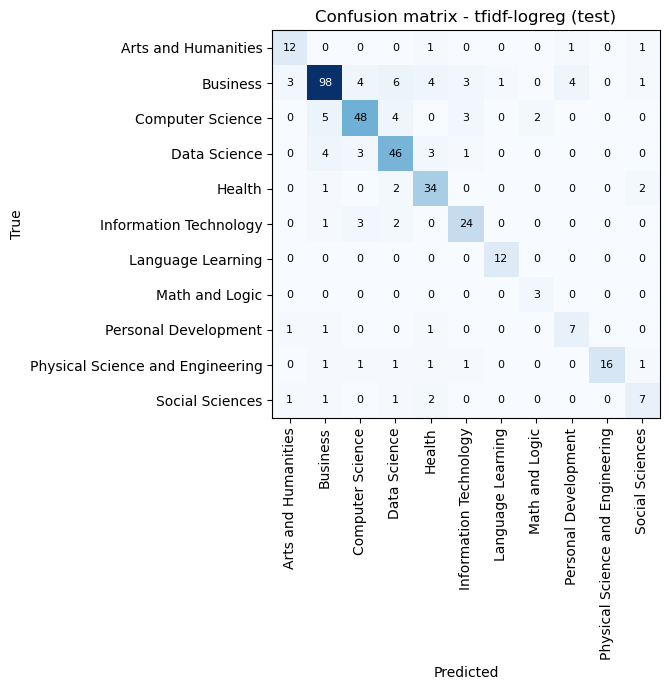

In [11]:
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix - {best_name} (test)")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
fig.tight_layout()
fig.savefig(DATA_PROCESSED / "model1_confusion.png", dpi=120)
plt.show()

## 7. Write results to files

Every number the report cites comes from these files, not the notebook (section 5).

In [12]:
report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
out = {
    "seed": SEED,
    "split_sizes": {"train": len(train), "dev": len(dev), "test": len(test)},
    "dev_comparison": dev_results,
    "test_best_model": best_name,
    "test_metrics": test_results[0],
    "test_per_class": {k: v for k, v in report.items()
                       if k not in ("accuracy", "macro avg", "weighted avg")},
    "test_macro_avg": report["macro avg"],
}
import platform
out["training_stats"] = {"tfidf-svd-mlp": mlp_stats,
                         "tfidf-logreg": {"train_seconds": round(logreg_train_s, 2)}}
out["environment"] = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "processor": platform.processor(),
}
(DATA_PROCESSED / "model1_results.json").write_text(
    json.dumps(out, indent=2, ensure_ascii=False), encoding="utf-8")

# --- human-readable report (marker-facing; mirrors model1_results.json) ---
env = out["environment"]
md = []
md.append("# Model 1 - Course to Category classifier: results\n")
md.append("_Generated by `notebooks/model1_classifier.ipynb` - do not edit by hand. "
          "Every figure here is also in `model1_results.json`._\n")
md.append("**Task.** Supervised multi-class text classification, 11 categories, on the frozen "
          "stratified split. Input = course title + short intro. Selection rule: best **dev "
          "macro-F1** picks the model; **test** is scored exactly once.\n")
md.append(f"- Split (seed {SEED}): train {len(train)} / dev {len(dev)} / test {len(test)} | "
          f"classes {train[LABEL_COL].nunique()}")
md.append("- Why macro-F1: classes are imbalanced (Business ~32%), so accuracy alone is "
          "misleading - a majority guesser scores ~0.32 accuracy but ~0.04 macro-F1.\n")

md.append("## Model comparison on dev (selection)\n")
md.append("| Model | Role | Accuracy | Macro-F1 | Inference (ms/item) |")
md.append("|---|---|---|---|---|")
role = {"majority-baseline": "baseline (floor)",
        "tfidf-logreg": "linear baseline",
        "tfidf-svd-mlp": "trained neural model"}
for r in dev_results:
    md.append(f"| {r['model']} | {role.get(r['model'], '')} | {r['accuracy']:.3f} | "
              f"{r['macro_f1']:.3f} | {r['infer_ms_per_item']:.2f} |")
md.append(f"\n**Selected: `{best_name}`** (highest dev macro-F1). The MLP is the trained neural "
          "model whose training statistics appear below; LogReg is the baseline that edged it on "
          "macro-F1.\n")

md.append(f"## Test result - `{best_name}`, scored once\n")
t = test_results[0]
md.append(f"- **Accuracy {t['accuracy']:.3f} | Macro-F1 {t['macro_f1']:.3f}** | "
          f"inference {t['infer_ms_per_item']:.2f} ms/item")
md.append(f"- Leakage check: macro-F1 {t['macro_f1']:.3f} < 0.90 -> healthy, no leakage smell "
          "(MODEL_PLAN.md section 7).\n")

md.append("### Per-class metrics (test)\n")
md.append("| Category | Precision | Recall | F1 | Support |")
md.append("|---|---|---|---|---|")
per = out["test_per_class"]
for cat in sorted(per):
    m = per[cat]
    md.append(f"| {cat} | {m['precision']:.2f} | {m['recall']:.2f} | {m['f1-score']:.2f} | "
              f"{int(m['support'])} |")
ma = out["test_macro_avg"]
md.append(f"| **macro avg** | {ma['precision']:.2f} | {ma['recall']:.2f} | {ma['f1-score']:.2f} | "
          f"{int(ma['support'])} |")
md.append("\nThe weakest classes are the smallest (Social Sciences, Personal Development, Math "
          "and Logic, 3-12 test items) - expected under the imbalance, and the reason macro-F1 is "
          "the headline metric.\n")

md.append("## Training statistics (MLP neural model)\n")
md.append(f"- Epochs run: {mlp_stats['epochs_run']} (max {mlp_stats['max_iter']}) | training "
          f"time {mlp_stats['train_seconds']}s | final training loss {mlp_stats['final_loss']}")
md.append(f"- Architecture: TF-IDF -> TruncatedSVD({mlp_stats['svd_components']}) -> "
          f"MLP hidden {mlp_stats['hidden_layer_sizes']}")
md.append(f"- LogReg baseline training time: {round(logreg_train_s, 2)}s")
md.append("- Figures: `model1_confusion.png` (confusion matrix), `model1_loss_curve.png` "
          "(training loss vs epoch)\n")

md.append("## Reproducibility\n")
md.append(f"- Seed {SEED}; environment: Python {env['python']} on {env['platform']}")
md.append("- Rerun: `python scripts/make_split.py`, then run this notebook (CSAI env, "
          "`environment.yml`).")

(DATA_PROCESSED / "model1_results.md").write_text("\n".join(md), encoding="utf-8")
print("Wrote model1_results.json / .md / confusion.png to", DATA_PROCESSED)

Wrote model1_results.json / .md / confusion.png to C:\Users\jimal\02_University\Year 4\Pre-master\Software Engineering for CSAI\Software-Engineering---Group-7\data\processed


## 8. Save the trained models

Persist the fitted pipelines so they can be loaded for inference without retraining (`joblib.load(path)`). Compressed to keep them small. Model 2 has no trained artefact - it is retrieval over a pretrained encoder plus a runtime-built index.

In [13]:
import joblib
saved = {}
for name, m in [("majority-baseline", majority), ("tfidf-logreg", logreg),
                ("tfidf-svd-mlp", mlp)]:
    path = DATA_PROCESSED / f"model1_{name}.joblib"
    joblib.dump(m, path, compress=3)
    saved[name] = path.name
print("Saved models:", saved)
print("Best (dev-selected):", best_name, "->", f"model1_{best_name}.joblib")

Saved models: {'majority-baseline': 'model1_majority-baseline.joblib', 'tfidf-logreg': 'model1_tfidf-logreg.joblib', 'tfidf-svd-mlp': 'model1_tfidf-svd-mlp.joblib'}
Best (dev-selected): tfidf-logreg -> model1_tfidf-logreg.joblib
